In [9]:
# ============================================================
# ⚙️  CONFIGURAZIONE MISCELE  — modifica solo questo blocco
# ============================================================
# Per ogni miscela definisci:
#   name            → etichetta (corrisponde anche alla cartella output/<name>)
#   input_dir       → cartella dei file di misura
#   src_file        → file con sorgente
#   nosrc_file      → file senza sorgente
#   src_voltage_tag / src_current_tag    → canali nel file con sorgente
#   nosrc_voltage_tag / nosrc_current_tag→ canali nel file senza sorgente
#   gain_peak_min_voltage                → soglia minima V per i punti di guadagno (None = nessun taglio)

MIXTURE_CONFIGS = [
    {
        'name':              'Ar_CO2_Iso_93_5_2',
        'input_dir':         'Ar_CO2_Iso_93_5_2',
        'src_file':          'MM2DNAP_Cor_Sorg_5_2.txt',
        'nosrc_file':        'MM2DNAP_Cor_No_Sorg_5_2.txt',
        'src_voltage_tag':   'V2',
        'src_current_tag':   'I2',
        'nosrc_voltage_tag': 'V2',
        'nosrc_current_tag': 'I2',
        'gain_peak_min_voltage': None,
    },
    {
        'name':              'Ar_CO2_Iso_88_10_2',
        'input_dir':         'Ar_CO2_Iso_88_10_2',
        'src_file':          'Cor_MM2DNAP_Sorg_10_2.txt',
        'nosrc_file':        'Cor_MM2DNAP_No_Sorg_10_2.txt',
        'src_voltage_tag':   'V2',
        'src_current_tag':   'I2',
        'nosrc_voltage_tag': 'V2',
        'nosrc_current_tag': 'I2',
        'gain_peak_min_voltage': 530.0,
    },
]


# Plot V2 e I2 per miscela
Questo notebook legge due file di testo (con sorgente e senza sorgente), estrae `V2` e `I2`, costruisce anche la curva `I2_diff = I2_sorg - I2_no_sorg` (interpolata in funzione della tensione) e disegna tutto su canvas ROOT.

La logica è organizzata per **miscele** (non per camere).
Esegui le celle in ordine e poi le celle finali per salvare canvas e tabelle in `output/<miscela>/`.

In [10]:
import re
from pathlib import Path
import pandas as pd

In [11]:
def parse_file(path, voltage_tag='V2', current_tag='I2'):
    """Legge un file di testo e restituisce DataFrame standard con colonne: time, V, I.
    voltage_tag/current_tag indicano i canali da leggere dall'header del file.
    """
    p = Path(path)
    text = p.read_text(encoding='utf-8', errors='ignore').splitlines()

    header_idx = None
    header_tokens = None
    for i, line in enumerate(text):
        if voltage_tag in line and current_tag in line:
            header_tokens = [tok.strip() for tok in line.split('\t') if tok.strip()]
            header_idx = i
            break

    if header_idx is None:
        raise ValueError(f"Header con '{voltage_tag}' e '{current_tag}' non trovato in {p}")

    df = pd.read_csv(p, sep='\t', header=None, skiprows=header_idx + 1, engine='python')

    data_tokens = [tok for tok in header_tokens if tok != '|']
    v_token_idx = next((ii for ii, t in enumerate(data_tokens) if re.search(rf'\b{re.escape(voltage_tag)}\b', t)), None)
    i_token_idx = next((ii for ii, t in enumerate(data_tokens) if re.search(rf'\b{re.escape(current_tag)}\b', t)), None)

    if v_token_idx is None or i_token_idx is None:
        raise ValueError(f"Non riesco a determinare gli indici di {voltage_tag} o {current_tag} dall'header")

    if v_token_idx >= len(df.columns) or i_token_idx >= len(df.columns):
        raise ValueError(
            f"Indici {voltage_tag} ({v_token_idx}) o {current_tag} ({i_token_idx}) fuori dai limiti. "
            f"DataFrame ha {len(df.columns)} colonne."
        )

    time_col_idx = 1 if len(df.columns) > 1 else 0
    timestamp_series = df.iloc[:, time_col_idx].astype(str).str.strip()

    # Prima prova con formato esplicito del file: HH:MM:SS.mmm dd/mm/YYYY
    times = pd.to_datetime(
        timestamp_series,
        format='%H:%M:%S.%f %d/%m/%Y',
        errors='coerce'
    )

    # Fallback: alcune righe potrebbero non avere i millisecondi
    if times.isna().any():
        missing = times.isna()
        times.loc[missing] = pd.to_datetime(
            timestamp_series.loc[missing],
            format='%H:%M:%S %d/%m/%Y',
            errors='coerce'
        )

    # Ultimo fallback conservativo
    if times.isna().all():
        times = pd.to_datetime(timestamp_series, dayfirst=True, errors='coerce')
        if times.isna().all():
            times = pd.to_datetime(timestamp_series, errors='coerce')

    v_series = pd.to_numeric(df.iloc[:, v_token_idx], errors='coerce')
    i_series = pd.to_numeric(df.iloc[:, i_token_idx], errors='coerce')

    out = pd.DataFrame({'time': times, 'V': v_series, 'I': i_series})
    out = out.dropna(subset=['time'])
    return out

In [12]:
def plot_series(dfs, labels=None, savepath=None, canvas_name=None, current_zero=False):
    import array
    import ROOT
    import numpy as np
    import pandas as pd

    ROOT.gROOT.SetBatch(True)
    ROOT.gStyle.SetOptStat(0)
    if canvas_name is None:
        canvas_name = f"c_{ROOT.TUUID().AsString().replace('-', '_')}"
    c = ROOT.TCanvas(canvas_name, 'Voltage and Current', 1200, 700)
    c.SetGrid()
    c.SetLeftMargin(0.12)
    c.SetRightMargin(0.18)

    leg = ROOT.TLegend(0.14, 0.74, 0.42, 0.89)
    leg.SetFillStyle(0)
    leg.SetBorderSize(0)
    leg.SetTextSize(0.03)

    i_colors = [
        ROOT.TColor.GetColor('#D55E00'),
        ROOT.TColor.GetColor('#009E73'),
        ROOT.TColor.GetColor('#CC79A7'),
    ]

    # Prepara timeline globale
    all_times = []
    for df in dfs:
        if 'time' not in df.columns:
            continue
        ts = pd.to_datetime(df['time'], errors='coerce')
        ts = ts[ts.notna()]
        if not ts.empty:
            all_times.append(ts)

    if not all_times:
        raise ValueError('Nessuna colonna time valida nei dataframe passati a plot_series.')

    t0 = min(ts.min() for ts in all_times)

    # Range corrente (dopo eventuale rimozione offset)
    i_chunks = []
    for df in dfs:
        if 'I' not in df.columns:
            continue
        ii = pd.to_numeric(df['I'], errors='coerce').to_numpy(dtype=float)
        ii = ii[np.isfinite(ii)]
        if ii.size:
            i_chunks.append(ii)

    if not i_chunks:
        raise ValueError('Nessuna colonna I valida nei dataframe passati a plot_series.')

    all_i_raw = np.concatenate(i_chunks)
    i_ref = np.nanmin(all_i_raw) if current_zero else 0.0
    all_i = all_i_raw - i_ref
    imin, imax = np.nanmin(all_i), np.nanmax(all_i)

    first = True
    voltage_in_legend = False
    drawn_objects = []

    # Prima passata: tensione + payload corrente, con consolidamento su x duplicati
    current_payload = []
    for i, df in enumerate(dfs):
        lab = labels[i] if labels else f'I {i+1}'

        t = pd.to_datetime(df['time'], errors='coerce') if 'time' in df.columns else pd.Series(dtype='datetime64[ns]')
        x_vals = (t - t0).dt.total_seconds().to_numpy(dtype=float) if len(t) else np.array([], dtype=float)

        if 'V' in df.columns and not df['V'].isna().all() and x_vals.size:
            y_vals_v = pd.to_numeric(df['V'], errors='coerce').to_numpy(dtype=float)
            valid_v = np.isfinite(x_vals) & np.isfinite(y_vals_v)
            if np.any(valid_v):
                xv = x_vals[valid_v]
                yv = y_vals_v[valid_v]
                vv = pd.DataFrame({'x': xv, 'y': yv}).groupby('x', as_index=False)['y'].mean().sort_values('x')
                g_v = ROOT.TGraph(len(vv), array.array('d', vv['x'].to_numpy(dtype=float)), array.array('d', vv['y'].to_numpy(dtype=float)))
                g_v.SetLineColor(ROOT.kBlue)
                g_v.SetLineWidth(2)
                g_v.SetMarkerStyle(0)
                g_v.SetMarkerSize(0)
                g_v.SetTitle('')
                g_v.GetXaxis().SetTitle('Tempo trascorso [s]')
                g_v.GetYaxis().SetTitle('Tensione [V]')
                g_v.GetYaxis().SetTitleColor(ROOT.kBlue + 1)
                g_v.GetYaxis().SetLabelColor(ROOT.kBlue + 1)
                g_v.GetYaxis().SetAxisColor(ROOT.kBlue + 1)

                if first:
                    g_v.Draw('AL')
                    first = False
                else:
                    g_v.Draw('L same')

                if not voltage_in_legend:
                    leg.AddEntry(g_v, 'V2', 'l')
                    voltage_in_legend = True

                drawn_objects.append(g_v)

        if 'I' in df.columns and not df['I'].isna().all() and x_vals.size:
            y_vals_i = pd.to_numeric(df['I'], errors='coerce').to_numpy(dtype=float) - i_ref
            valid_i = np.isfinite(x_vals) & np.isfinite(y_vals_i)
            if np.any(valid_i):
                xi = x_vals[valid_i]
                yi = y_vals_i[valid_i]
                ii_df = pd.DataFrame({'x': xi, 'y': yi}).groupby('x', as_index=False)['y'].mean().sort_values('x')
                current_payload.append((i, lab, ii_df['x'].to_numpy(dtype=float), ii_df['y'].to_numpy(dtype=float)))

    # Aggiorna per leggere il range asse sinistro realmente visualizzato
    c.Modified()
    c.Update()
    y_low = ROOT.gPad.GetUymin()
    y_high = ROOT.gPad.GetUymax()

    # Scala corrente -> asse sinistro usando il range visualizzato
    if (imax - imin) == 0:
        scale = 1.0
    else:
        scale = (y_high - y_low) / (imax - imin)
    offset = y_low - imin * scale

    # Seconda passata: correnti
    for i, lab, x_arr, y_arr in current_payload:
        y_vals_i_scaled = y_arr * scale + offset
        g_i = ROOT.TGraph(len(x_arr), array.array('d', x_arr), array.array('d', y_vals_i_scaled))
        color = i_colors[i % len(i_colors)]
        g_i.SetLineColor(color)
        g_i.SetLineWidth(2)
        g_i.SetMarkerStyle(0)
        g_i.SetMarkerSize(0)
        g_i.Draw('L same')
        leg.AddEntry(g_i, lab, 'l')
        drawn_objects.append(g_i)

    # Asse destro corrente
    x_right = ROOT.gPad.GetUxmax()
    axis = ROOT.TGaxis(x_right, y_low, x_right, y_high, imin, imax, 510, '+R')
    axis.SetTitle('Corrente [uA] (offset rimosso)' if current_zero else 'Corrente [uA]')
    axis.SetTitleColor(ROOT.kRed)
    axis.SetLabelColor(ROOT.kRed)
    axis.SetLineColor(ROOT.kRed)
    axis.Draw()
    drawn_objects.append(axis)

    leg.Draw()
    drawn_objects.append(leg)
    c.Modified()
    c._keepalive = drawn_objects

    if savepath:
        root_path = f'{savepath}.root'
        png_path = f'{savepath}.png'
        c.SaveAs(root_path)
        c.SaveAs(png_path)
        print(f'Saved ROOT canvas to {root_path}')
        print(f'Saved PNG to {png_path}')
    return c

In [13]:
# Cella legacy (versione a camere) disattivata
print("Questa cella legacy a camere è stata disattivata.")
print("Usa la pipeline per miscele (cella 8) e il plot per miscele (cella 6).")

Questa cella legacy a camere è stata disattivata.
Usa la pipeline per miscele (cella 8) e il plot per miscele (cella 6).


In [21]:
# Plot delle correnti medie per step di voltaggio: sorgente, no_sorg e differenza
import array
from pathlib import Path

import numpy as np
import pandas as pd
import ROOT

ROOT.gROOT.SetBatch(True)
ROOT.gStyle.SetOptStat(0)

output_dir = Path('output')
plot_summary = []
VOLTAGE_BIN_STEP = 5.0

for cfg in MIXTURE_CONFIGS:
    mixture = cfg['name']
    input_dir = Path(cfg['input_dir'])
    src_path = input_dir / cfg['src_file']
    nosrc_path = input_dir / cfg['nosrc_file']

    if not src_path.exists() or not nosrc_path.exists():
        print(f'[{mixture}] file mancanti: {src_path} / {nosrc_path} — salto.')
        continue

    src_df = parse_file(
        src_path,
        voltage_tag=cfg['src_voltage_tag'],
        current_tag=cfg['src_current_tag'],
    ).copy()
    nosrc_df = parse_file(
        nosrc_path,
        voltage_tag=cfg['nosrc_voltage_tag'],
        current_tag=cfg['nosrc_current_tag'],
    ).copy()

    src_df['V_round'] = (pd.to_numeric(src_df['V'], errors='coerce') / VOLTAGE_BIN_STEP).round() * VOLTAGE_BIN_STEP
    nosrc_df['V_round'] = (pd.to_numeric(nosrc_df['V'], errors='coerce') / VOLTAGE_BIN_STEP).round() * VOLTAGE_BIN_STEP

    src_grouped = src_df.groupby('V_round')['I'].agg(['mean', 'std', 'count']).reset_index()
    src_grouped.columns = ['V', 'I_sorg_mean', 'I_sorg_std', 'n_sorg']

    nosrc_grouped = nosrc_df.groupby('V_round')['I'].agg(['mean', 'std', 'count']).reset_index()
    nosrc_grouped.columns = ['V', 'I_no_sorg_mean', 'I_no_sorg_std', 'n_no_sorg']

    merged_means = pd.merge(src_grouped, nosrc_grouped, on='V', how='inner').sort_values('V').reset_index(drop=True)
    if merged_means.empty:
        print(f'[{mixture}] nessun bin di tensione comune tra sorgente e no_sorg.')
        continue

    merged_means['I_diff_mean'] = merged_means['I_sorg_mean'] - merged_means['I_no_sorg_mean']
    merged_means['I_sorg_err'] = (merged_means['I_sorg_std'] / np.sqrt(merged_means['n_sorg'])).fillna(0.0)
    merged_means['I_no_sorg_err'] = (merged_means['I_no_sorg_std'] / np.sqrt(merged_means['n_no_sorg'])).fillna(0.0)
    merged_means['I_diff_err'] = np.sqrt(merged_means['I_sorg_err']**2 + merged_means['I_no_sorg_err']**2)

    print(f'\n===== {mixture} =====')
    print(f'Step di binning in tensione: {VOLTAGE_BIN_STEP:g} V')
    print(merged_means[['V', 'I_sorg_mean', 'I_no_sorg_mean', 'I_diff_mean']].to_string(index=False))

    v_arr = array.array('d', merged_means['V'].to_numpy(dtype=float))
    ev_arr = array.array('d', np.zeros(len(merged_means), dtype=float))

    i_sorg_arr = array.array('d', merged_means['I_sorg_mean'].to_numpy(dtype=float))
    ei_sorg_arr = array.array('d', merged_means['I_sorg_err'].to_numpy(dtype=float))

    i_nosorg_arr = array.array('d', merged_means['I_no_sorg_mean'].to_numpy(dtype=float))
    ei_nosorg_arr = array.array('d', merged_means['I_no_sorg_err'].to_numpy(dtype=float))

    i_diff_arr = array.array('d', merged_means['I_diff_mean'].to_numpy(dtype=float))
    ei_diff_arr = array.array('d', merged_means['I_diff_err'].to_numpy(dtype=float))

    g_sorg = ROOT.TGraphErrors(len(v_arr), v_arr, i_sorg_arr, ev_arr, ei_sorg_arr)
    g_nosorg = ROOT.TGraphErrors(len(v_arr), v_arr, i_nosorg_arr, ev_arr, ei_nosorg_arr)
    g_diff = ROOT.TGraphErrors(len(v_arr), v_arr, i_diff_arr, ev_arr, ei_diff_arr)

    color_sorg = ROOT.TColor.GetColor('#D55E00')
    color_nosorg = ROOT.TColor.GetColor('#009E73')
    color_diff = ROOT.TColor.GetColor('#CC79A7')

    for graph, color, marker in [
        (g_sorg, color_sorg, 20),
        (g_nosorg, color_nosorg, 21),
        (g_diff, color_diff, 22),
    ]:
        graph.SetMarkerColor(color)
        graph.SetLineColor(color)
        graph.SetMarkerStyle(marker)
        graph.SetMarkerSize(0.9)
        graph.SetLineWidth(2)
        graph.SetTitle('')

    c_mean = ROOT.TCanvas(f'c_{mixture}_Imean_vs_V', f'Correnti medie vs V - {mixture}', 1000, 700)
    c_mean.SetGrid()
    c_mean.SetLeftMargin(0.13)
    c_mean.SetRightMargin(0.05)

    g_sorg.Draw('AP')
    g_sorg.GetXaxis().SetTitle('Tensione [V]')
    g_sorg.GetYaxis().SetTitle('Corrente media [#muA]')

    g_nosorg.Draw('P same')
    g_diff.Draw('P same')

    leg = ROOT.TLegend(0.14, 0.74, 0.52, 0.90)
    leg.SetFillStyle(0)
    leg.SetBorderSize(0)
    leg.SetTextSize(0.04)
    leg.AddEntry(g_sorg, 'I_{2,sorg} media', 'p')
    leg.AddEntry(g_nosorg, 'I_{2,no sorg} media', 'p')
    leg.AddEntry(g_diff, 'I_{2,sorg} - I_{2,no sorg}', 'p')
    leg.Draw()

    out_base = output_dir / mixture / f'{mixture}_Imean_vs_V'
    c_mean.SaveAs(str(out_base.with_suffix('.root')))
    c_mean.SaveAs(str(out_base.with_suffix('.png')))
    print(f'[{mixture}] Salvato: {out_base}.root / .png')

    plot_summary.append({
        'miscela': mixture,
        'plot_root': str(out_base.with_suffix('.root')),
        'plot_png': str(out_base.with_suffix('.png')),
        'n_bins': int(len(merged_means)),
    })

print('\n===== RIEPILOGO PLOT MEDIE =====')
print(pd.DataFrame(plot_summary).to_string(index=False) if plot_summary else 'Nessun plot generato.')


===== Ar_CO2_Iso_93_5_2 =====
Step di binning in tensione: 5 V
    V  I_sorg_mean  I_no_sorg_mean  I_diff_mean
490.0    -0.000916       -0.002163     0.001247
500.0    -0.000458       -0.002103     0.001645
510.0     0.000095       -0.002089     0.002183
515.0     0.000456       -0.002086     0.002542
520.0     0.000946       -0.002065     0.003011
525.0     0.001504       -0.002037     0.003541
530.0     0.002317       -0.002011     0.004328
535.0     0.003485       -0.002006     0.005491
540.0     0.005528       -0.001981     0.007509
545.0     0.009986       -0.001943     0.011929
550.0     0.021430       -0.001906     0.023336
555.0     0.045141       -0.001841     0.046982
560.0     0.101064        0.000943     0.100121
565.0     0.193853        0.009386     0.184467
570.0     0.362400        0.112689     0.249711
575.0     0.676611        0.369199     0.307413
[Ar_CO2_Iso_93_5_2] Salvato: output/Ar_CO2_Iso_93_5_2/Ar_CO2_Iso_93_5_2_Imean_vs_V.root / .png

===== Ar_CO2_Iso_88_10_2

Info in <TCanvas::SaveAs>: ROOT file output/Ar_CO2_Iso_93_5_2/Ar_CO2_Iso_93_5_2_Imean_vs_V.root has been created
Info in <TCanvas::Print>: png file output/Ar_CO2_Iso_93_5_2/Ar_CO2_Iso_93_5_2_Imean_vs_V.png has been created
Info in <TCanvas::SaveAs>: ROOT file output/Ar_CO2_Iso_88_10_2/Ar_CO2_Iso_88_10_2_Imean_vs_V.root has been created
Info in <TCanvas::Print>: png file output/Ar_CO2_Iso_88_10_2/Ar_CO2_Iso_88_10_2_Imean_vs_V.png has been created


### Note
- Se i tuoi file hanno formati diversi per il timestamp o separatori differenti, copia la cella `parse_file` e adattala.
- Per plottare più file insieme, imposta `dfs = [parse_file(p1), parse_file(p2), ...]` e chiama `plot_series(dfs, labels=[...])`.
- Se vuoi che converta la corrente da uA ad A, posso aggiungere un'opzione per la conversione.

In [15]:
# Pipeline per miscele: lettura con/senza sorgente su V2/I2
from pathlib import Path
import numpy as np
import pandas as pd
import ROOT

output_dir = Path('output')
output_dir.mkdir(parents=True, exist_ok=True)


def interpolate_current_by_voltage(v_ref, v_curve, i_curve):
    """Interpolazione lineare di I(V) su v_ref. Fuori range restituisce NaN."""
    ref = pd.to_numeric(v_ref, errors='coerce').to_numpy(dtype=float)

    tmp = pd.DataFrame({'V': pd.to_numeric(v_curve, errors='coerce'), 'I': pd.to_numeric(i_curve, errors='coerce')})
    tmp = tmp.dropna(subset=['V', 'I'])
    if tmp.empty:
        return np.full(ref.shape, np.nan, dtype=float)

    grouped = tmp.groupby('V', as_index=False)['I'].mean().sort_values('V')
    v_sorted = grouped['V'].to_numpy(dtype=float)
    i_sorted = grouped['I'].to_numpy(dtype=float)

    if len(v_sorted) == 1:
        out = np.full(ref.shape, np.nan, dtype=float)
        out[np.isfinite(ref) & np.isclose(ref, v_sorted[0])] = i_sorted[0]
        return out

    return np.interp(ref, v_sorted, i_sorted, left=np.nan, right=np.nan)


summary_rows = []

for cfg in MIXTURE_CONFIGS:
    mixture     = cfg['name']
    input_dir   = Path(cfg['input_dir'])
    src_v_tag   = cfg['src_voltage_tag']
    src_i_tag   = cfg['src_current_tag']
    nosrc_v_tag = cfg['nosrc_voltage_tag']
    nosrc_i_tag = cfg['nosrc_current_tag']

    src_path   = input_dir / cfg['src_file']
    nosrc_path = input_dir / cfg['nosrc_file']

    if not src_path.exists() or not nosrc_path.exists():
        print(f"[{mixture}] file mancanti: {src_path} / {nosrc_path} — salto.")
        continue

    src_df   = parse_file(src_path,   voltage_tag=src_v_tag,   current_tag=src_i_tag).sort_values('time')
    nosrc_df = parse_file(nosrc_path, voltage_tag=nosrc_v_tag, current_tag=nosrc_i_tag).sort_values('time')

    src_selected_df = src_df[['time', 'V', 'I']].rename(
        columns={'V': f'V_{src_v_tag}_sorg', 'I': f'I_{src_i_tag}_sorg'}
    )
    nosrc_selected_df = nosrc_df[['time', 'V', 'I']].rename(
        columns={'V': f'V_{nosrc_v_tag}_no_sorg', 'I': f'I_{nosrc_i_tag}_no_sorg'}
    )

    # Interpolazione no_sorg sulla base V del sorgente (solo per tabella di confronto)
    i_no_sorg_interp = interpolate_current_by_voltage(
        src_df['V'], nosrc_df['V'], nosrc_df['I'],
    )

    merged = src_df[['time', 'V', 'I']].copy()
    merged.columns = ['time', 'V2', 'I2_sorg']
    merged['I2_no_sorg_interp'] = i_no_sorg_interp
    merged['I2_diff'] = merged['I2_sorg'] - merged['I2_no_sorg_interp']

    # Se manca I_sorg o I_no_sorg_interp, punto escluso
    valid_curr_mask = merged['I2_sorg'].notna() & merged['I2_no_sorg_interp'].notna()
    n_total = len(merged)
    n_valid = int(valid_curr_mask.sum())
    n_dropped_missing_current = int((~valid_curr_mask).sum())

    merged_valid = merged.loc[valid_curr_mask].copy().reset_index(drop=True)

    # Plot con sorgente: dati validi allineati
    sorg_df = merged_valid[['time', 'V2', 'I2_sorg']].rename(columns={'V2': 'V', 'I2_sorg': 'I'}).copy()

    # Plot senza sorgente: DATI SPERIMENTALI RAW dal .txt (nessun smoothing/interpolazione)
    no_sorg_df = nosrc_df[['time', 'V', 'I']].copy()
    no_sorg_df = no_sorg_df.dropna(subset=['time', 'V', 'I']).sort_values('time').reset_index(drop=True)

    if merged_valid.empty:
        print(f"[{mixture}] nessun punto valido dopo il filtro correnti (I_sorg / I_no_sorg). Salto output.")
        summary_rows.append({
            'miscela':                    mixture,
            'canale_tensione_sorg':        src_v_tag,
            'canale_corrente_sorg':        src_i_tag,
            'canale_tensione_no_sorg':     nosrc_v_tag,
            'canale_corrente_no_sorg':     nosrc_i_tag,
            'n_righe_originali':           int(n_total),
            'n_righe':                     0,
            'n_scartate_corrente_mancante': int(n_dropped_missing_current),
            'n_interp_valide':             0,
            'n_fuori_range_tensione':      int(n_dropped_missing_current),
            'I2_no_sorg_abs_max':          float('nan'),
            'root':                        '',
            'png':                         '',
            'root_no_sorg':                '',
            'png_no_sorg':                 '',
            'csv':                         '',
            'csv_input_sorg':              '',
            'csv_input_no_sorg':           '',
        })
        continue

    mixture_out = output_dir / mixture
    mixture_out.mkdir(parents=True, exist_ok=True)

    output_base_sorg = mixture_out / f'{mixture}_sorg_only'
    output_base_no_sorg = mixture_out / f'{mixture}_no_sorg_only'
    print(f'[{mixture}] output_sorg = {output_base_sorg}')
    print(f'[{mixture}] output_no_sorg = {output_base_no_sorg}')

    for stale in [
        mixture_out / f'{mixture}_no_sorg_diff.png',
        mixture_out / f'{mixture}_no_sorg_diff.root',
        mixture_out / f'{mixture}_Idiff_vs_V.png',
        mixture_out / f'{mixture}_Idiff_vs_V.root',
    ]:
        if stale.exists():
            stale.unlink()
            print(f'[{mixture}] rimosso file obsoleto: {stale}')

    canvas_sorg = plot_series(
        [sorg_df],
        labels=[f'{mixture} I2_sorg'],
        savepath=None,
        canvas_name=f'c_{mixture}_sorg',
        current_zero=True,
    )

    canvas_sorg.SetName(f'c_{mixture}_sorg')
    root_path = output_base_sorg.with_suffix('.root')
    root_file = ROOT.TFile(str(root_path), 'RECREATE')
    root_file.cd()
    canvas_sorg.Write(canvas_sorg.GetName())
    root_file.Close()

    png_path = output_base_sorg.with_suffix('.png')
    canvas_sorg.SaveAs(str(png_path))

    canvas_no_sorg = plot_series(
        [no_sorg_df],
        labels=[f'{mixture} I2_no_sorg (raw txt)'],
        savepath=None,
        canvas_name=f'c_{mixture}_no_sorg_only',
        current_zero=True,
    )

    canvas_no_sorg.SetName(f'c_{mixture}_no_sorg_only')
    root_no_sorg_path = output_base_no_sorg.with_suffix('.root')
    root_no_sorg_file = ROOT.TFile(str(root_no_sorg_path), 'RECREATE')
    root_no_sorg_file.cd()
    canvas_no_sorg.Write(canvas_no_sorg.GetName())
    root_no_sorg_file.Close()

    png_no_sorg_path = output_base_no_sorg.with_suffix('.png')
    canvas_no_sorg.SaveAs(str(png_no_sorg_path))

    table_df  = merged_valid[['time', 'V2', 'I2_sorg', 'I2_no_sorg_interp', 'I2_diff']].copy()
    table_df  = table_df.rename(columns={'V2': 'V2_ref'})
    csv_path  = mixture_out / f'{mixture}_I_table.csv'
    table_df.to_csv(csv_path, index=False)

    src_cols_csv   = mixture_out / f'{mixture}_selected_columns_sorg.csv'
    nosrc_cols_csv = mixture_out / f'{mixture}_selected_columns_no_sorg.csv'
    src_selected_df.to_csv(src_cols_csv, index=False)
    nosrc_selected_df.to_csv(nosrc_cols_csv, index=False)

    print(f"\n=== {mixture} ===")
    print(f"Colonne: sorgente=({src_v_tag}, {src_i_tag}) | no_sorg=({nosrc_v_tag}, {nosrc_i_tag})")
    print('Anteprima tabella input sorgente:')
    print(src_selected_df.head(10).to_string(index=False))
    print('Anteprima tabella input no_sorg:')
    print(nosrc_selected_df.head(10).to_string(index=False))
    print('Tempi e correnti no_sorg RAW (prime 20 righe):')
    print(no_sorg_df[['time', 'I']].head(20).to_string(index=False))
    print('Tempi e correnti no_sorg RAW (ultime 20 righe):')
    print(no_sorg_df[['time', 'I']].tail(20).to_string(index=False))
    print('Anteprima tabella finale interpolata (solo punti validi):')
    print(table_df.head(10).to_string(index=False))

    summary_rows.append({
        'miscela':                    mixture,
        'canale_tensione_sorg':        src_v_tag,
        'canale_corrente_sorg':        src_i_tag,
        'canale_tensione_no_sorg':     nosrc_v_tag,
        'canale_corrente_no_sorg':     nosrc_i_tag,
        'n_righe_originali':           int(n_total),
        'n_righe':                     len(table_df),
        'n_scartate_corrente_mancante': int(n_dropped_missing_current),
        'n_interp_valide':             int(n_valid),
        'n_fuori_range_tensione':      int(n_dropped_missing_current),
        'I2_no_sorg_abs_max':          float(table_df['I2_no_sorg_interp'].abs().max(skipna=True)),
        'root':                        str(root_path),
        'png':                         str(png_path),
        'root_no_sorg':                str(root_no_sorg_path),
        'png_no_sorg':                 str(png_no_sorg_path),
        'csv':                         str(csv_path),
        'csv_input_sorg':              str(src_cols_csv),
        'csv_input_no_sorg':           str(nosrc_cols_csv),
    })

    try:
        canvas_sorg.Close()
    except Exception:
        pass

    try:
        canvas_no_sorg.Close()
    except Exception:
        pass

summary_df = pd.DataFrame(summary_rows)
print('\n===== RIEPILOGO =====')
print(summary_df.to_string(index=False))


Welcome to JupyROOT 6.28/04
[Ar_CO2_Iso_93_5_2] output_sorg = output/Ar_CO2_Iso_93_5_2/Ar_CO2_Iso_93_5_2_sorg_only
[Ar_CO2_Iso_93_5_2] output_no_sorg = output/Ar_CO2_Iso_93_5_2/Ar_CO2_Iso_93_5_2_no_sorg_only


Info in <TCanvas::Print>: png file output/Ar_CO2_Iso_93_5_2/Ar_CO2_Iso_93_5_2_sorg_only.png has been created
Info in <TCanvas::Print>: png file output/Ar_CO2_Iso_93_5_2/Ar_CO2_Iso_93_5_2_no_sorg_only.png has been created
Info in <TCanvas::Print>: png file output/Ar_CO2_Iso_88_10_2/Ar_CO2_Iso_88_10_2_sorg_only.png has been created
Info in <TCanvas::Print>: png file output/Ar_CO2_Iso_88_10_2/Ar_CO2_Iso_88_10_2_no_sorg_only.png has been created



=== Ar_CO2_Iso_93_5_2 ===
Colonne: sorgente=(V2, I2) | no_sorg=(V2, I2)
Anteprima tabella input sorgente:
                   time  V_V2_sorg  I_I2_sorg
2026-06-29 11:36:51.719      490.0   -0.00090
2026-06-29 11:36:52.599      490.0   -0.00090
2026-06-29 11:36:53.478      490.0   -0.00090
2026-06-29 11:36:54.356      490.0   -0.00095
2026-06-29 11:36:55.245      490.0   -0.00095
2026-06-29 11:36:56.123      490.0   -0.00090
2026-06-29 11:36:57.002      490.0   -0.00090
2026-06-29 11:36:57.879      490.0   -0.00090
2026-06-29 11:36:58.758      490.0   -0.00095
2026-06-29 11:36:59.647      490.0   -0.00095
Anteprima tabella input no_sorg:
                   time  V_V2_no_sorg  I_I2_no_sorg
2026-06-29 13:29:15.468         490.1      -0.00190
2026-06-29 13:29:16.349         490.1      -0.00205
2026-06-29 13:29:17.227         490.1      -0.00205
2026-06-29 13:29:18.106         490.1      -0.00210
2026-06-29 13:29:18.985         490.1      -0.00210
2026-06-29 13:29:19.865         490.1     

In [16]:
# Cella legacy disattivata
print("Questa cella legacy è disattivata per evitare conflitti con la logica per miscele (V2/I2).")
print("Usa la pipeline principale (cella 9) per generare i plot sorg_only e no_sorg_only.")

Questa cella legacy è disattivata per evitare conflitti con la logica per miscele (V2/I2).
Usa la pipeline principale (cella 9) per generare i plot sorg_only e no_sorg_only.


In [17]:
# Diagnostica corrente: con sorgente, senza sorgente e differenza (logica per miscela, V2/I2)
from pathlib import Path

if 'table_df' in globals() and {'time', 'I2_sorg', 'I2_no_sorg_interp', 'I2_diff'}.issubset(table_df.columns):
    check_df = table_df[['time', 'I2_sorg', 'I2_no_sorg_interp', 'I2_diff']].copy()
elif 'merged' in globals() and {'time', 'I2_sorg', 'I2_no_sorg_interp', 'I2_diff'}.issubset(merged.columns):
    check_df = merged[['time', 'I2_sorg', 'I2_no_sorg_interp', 'I2_diff']].copy()
else:
    raise RuntimeError("Variabili non disponibili: esegui prima la pipeline per miscele (cella 8).")

print('Prime 20 righe:')
print(check_df.head(20).to_string(index=False))

print('\nUltime 20 righe:')
print(check_df.tail(20).to_string(index=False))

print('\nStatistiche principali:')
print(check_df[['I2_sorg', 'I2_no_sorg_interp', 'I2_diff']].describe().to_string())

is_nosorg_all_zero = (check_df['I2_no_sorg_interp'].abs() < 1e-12).all()
print(f"\nI2_no_sorg_interp è (quasi) sempre zero? {is_nosorg_all_zero}")
print(f"Valore assoluto massimo I2_no_sorg_interp: {check_df['I2_no_sorg_interp'].abs().max():.6g}")

if 'mixture' in globals() and isinstance(mixture, str):
    csv_path = Path('output') / mixture / f'{mixture}_I_table_debug.csv'
else:
    csv_path = Path('output') / 'I_table_debug.csv'
csv_path.parent.mkdir(parents=True, exist_ok=True)

check_df.to_csv(csv_path, index=False)
print(f"CSV scritto in: {csv_path.resolve()}")

Prime 20 righe:
                   time  I2_sorg  I2_no_sorg_interp  I2_diff
2026-06-29 15:51:31.401 -0.00225          -0.003108 0.000858
2026-06-29 15:51:32.291 -0.00230          -0.003108 0.000808
2026-06-29 15:51:33.171 -0.00230          -0.003108 0.000808
2026-06-29 15:51:34.051 -0.00230          -0.003108 0.000808
2026-06-29 15:51:34.929 -0.00230          -0.003108 0.000808
2026-06-29 15:51:35.810 -0.00240          -0.003108 0.000708
2026-06-29 15:51:36.690 -0.00240          -0.003108 0.000708
2026-06-29 15:51:37.559 -0.00240          -0.003108 0.000708
2026-06-29 15:51:38.439 -0.00240          -0.003108 0.000708
2026-06-29 15:51:39.318 -0.00240          -0.003108 0.000708
2026-06-29 15:51:40.564 -0.00240          -0.003108 0.000708
2026-06-29 15:51:41.454 -0.00240          -0.003108 0.000708
2026-06-29 15:51:42.400 -0.00240          -0.003108 0.000708
2026-06-29 15:51:43.280 -0.00240          -0.003108 0.000708
2026-06-29 15:51:44.396 -0.00240          -0.003108 0.000708
2026-06-

In [18]:
# Loader automatico gain_data per miscela: cerca in output/<miscela>/gain_data.py oppure .json
from pathlib import Path
import importlib.util
import json

base_dir = Path.cwd()
output_dir = base_dir / 'output'

mixture_configs = globals().get('MIXTURE_CONFIGS', [])
mixtures = [cfg.get('name') for cfg in mixture_configs if isinstance(cfg, dict) and cfg.get('name')]

if not mixtures and output_dir.exists():
    mixtures = [p.name for p in output_dir.iterdir() if p.is_dir()]

gain_data = {}

for mixture in mixtures:
    py_gain = output_dir / mixture / 'gain_data.py'
    json_gain = output_dir / mixture / 'gain_data.json'

    if py_gain.exists():
        spec = importlib.util.spec_from_file_location(f'gain_data_module_{mixture}', str(py_gain))
        mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(mod)
        loaded = getattr(mod, 'gain_data', {})
        if mixture in loaded and isinstance(loaded[mixture], dict):
            gain_data[mixture] = {float(v): float(g) for v, g in loaded[mixture].items()}
        else:
            gain_data[mixture] = {float(v): float(g) for v, g in loaded.items()} if isinstance(loaded, dict) else {}
        print(f'[{mixture}] Caricato gain_data da file Python: {py_gain}')
    elif json_gain.exists():
        raw = json.loads(json_gain.read_text(encoding='utf-8'))
        if mixture in raw and isinstance(raw[mixture], dict):
            gain_data[mixture] = {float(v): float(g) for v, g in raw[mixture].items()}
        else:
            gain_data[mixture] = {float(v): float(g) for v, g in raw.items()} if isinstance(raw, dict) else {}
        print(f'[{mixture}] Caricato gain_data da file JSON: {json_gain}')
    else:
        gain_data[mixture] = {}
        print(f'[{mixture}] Nessun gain_data.py/json trovato: uso dizionario vuoto.')

print('Miscele disponibili in gain_data:', list(gain_data.keys()))

[Ar_CO2_Iso_93_5_2] Caricato gain_data da file Python: /Users/adelinadonofrio/Desktop/MPGD/output/Ar_CO2_Iso_93_5_2/gain_data.py
[Ar_CO2_Iso_88_10_2] Caricato gain_data da file Python: /Users/adelinadonofrio/Desktop/MPGD/output/Ar_CO2_Iso_88_10_2/gain_data.py
Miscele disponibili in gain_data: ['Ar_CO2_Iso_93_5_2', 'Ar_CO2_Iso_88_10_2']


In [19]:
import array
import numpy as np
import ROOT
import pandas as pd
from pathlib import Path

ROOT.gROOT.SetBatch(True)
ROOT.gStyle.SetOptStat(0)

if 'gain_data' not in globals() or gain_data is None:
    gain_data = {}
    print('Attenzione: gain_data non caricato dal loader, uso dizionario vuoto.')

output_dir = Path('output')
mixture_configs = globals().get('MIXTURE_CONFIGS', [])
mixtures = [cfg.get('name') for cfg in mixture_configs if isinstance(cfg, dict) and cfg.get('name')]
cfg_by_name = {cfg.get('name'): cfg for cfg in mixture_configs if isinstance(cfg, dict) and cfg.get('name')}
VOLTAGE_BIN_STEP = 5.0

if not mixtures and output_dir.exists():
    mixtures = [p.name for p in output_dir.iterdir() if p.is_dir()]

palette = [
    ROOT.TColor.GetColor('#D55E00'),
    ROOT.TColor.GetColor('#009E73'),
    ROOT.TColor.GetColor('#CC79A7'),
    ROOT.TColor.GetColor('#0072B2'),
    ROOT.TColor.GetColor('#E69F00'),
    ROOT.TColor.GetColor('#56B4E9'),
]

for idx, mixture in enumerate(mixtures):
    mixture_out = output_dir / mixture
    csv_candidates = [
        mixture_out / f'{mixture}_I_table.csv',
        mixture_out / f'{mixture}_I_table_debug.csv',
    ]
    csv_path = next((p for p in csv_candidates if p.exists()), None)
    if csv_path is None:
        print(f'[{mixture}] nessun CSV trovato, salto.')
        continue

    table_df = pd.read_csv(csv_path)
    v_candidates = [c for c in table_df.columns if c.startswith('V2')]
    if not v_candidates:
        v_candidates = [c for c in table_df.columns if c.startswith('V_')]
    if not v_candidates:
        print(f'[{mixture}] colonna tensione non trovata, salto.')
        continue
    v_col = v_candidates[0]

    diff_col = 'I2_diff' if 'I2_diff' in table_df.columns else ('I_diff' if 'I_diff' in table_df.columns else 'I3_diff')
    if diff_col not in table_df.columns:
        print(f'[{mixture}] colonna differenza non trovata, salto.')
        continue

    work = table_df[[v_col, diff_col]].copy()
    work.columns = ['V', 'I_diff']
    # Allineamento con il plot I2_diff: binning a step di 5 V
    work['V_round'] = (work['V'] / VOLTAGE_BIN_STEP).round() * VOLTAGE_BIN_STEP
    grouped = work.groupby('V_round')['I_diff'].agg(['mean', 'std', 'count']).reset_index()
    grouped.columns = ['V', 'I_diff_mean', 'I_diff_std', 'n']
    grouped = grouped[grouped['I_diff_mean'] > 0].sort_values('V').reset_index(drop=True)

    if grouped.empty:
        print(f'[{mixture}] nessun punto positivo per I_diff, salto.')
        continue

    color_i = palette[idx % len(palette)]
    color_g = palette[(idx + 2) % len(palette)]

    v_i_arr  = array.array('d', grouped['V'].to_numpy(dtype=float))
    i_arr    = array.array('d', grouped['I_diff_mean'].to_numpy(dtype=float))
    ev_i_arr = array.array('d', np.zeros(len(grouped), dtype=float))
    ei_arr   = array.array('d', (grouped['I_diff_std'] / np.sqrt(grouped['n'])).fillna(0).to_numpy(dtype=float))

    g_current = ROOT.TGraphErrors(len(v_i_arr), v_i_arr, i_arr, ev_i_arr, ei_arr)
    g_current.SetTitle('')
    g_current.SetMarkerStyle(20)
    g_current.SetMarkerSize(0.8)
    g_current.SetMarkerColor(color_i)
    g_current.SetLineColor(color_i)
    g_current.SetLineWidth(2)

    gd_raw = gain_data.get(mixture, {}) if isinstance(gain_data, dict) else {}
    gain_min_v = cfg_by_name.get(mixture, {}).get('gain_peak_min_voltage', None)
    if gain_min_v is not None:
        gd = {float(v): float(g) for v, g in gd_raw.items() if float(v) >= float(gain_min_v)}
        print(f'[{mixture}] guadagno: applicato taglio V >= {float(gain_min_v):g} ({len(gd)}/{len(gd_raw)} punti)')
    else:
        gd = gd_raw

    has_gain = len(gd) > 0

    c_cg = ROOT.TCanvas(f'c_{mixture}_I_gain', f'Corrente e Guadagno - {mixture}', 1000, 700)
    c_cg.SetGrid()
    c_cg.SetLeftMargin(0.13)
    c_cg.SetRightMargin(0.16)

    g_current.Draw('APL')
    g_current.GetXaxis().SetTitle('Tensione [V]')
    g_current.GetYaxis().SetTitle('I_{2,diff} media [#muA]')
    g_current.GetYaxis().SetTitleColor(color_i)
    g_current.GetYaxis().SetLabelColor(color_i)
    g_current.GetYaxis().SetAxisColor(color_i)
    c_cg.SetLogy(0)

    # Legge il range reale visualizzato sull'asse sinistro
    c_cg.Modified()
    c_cg.Update()
    y_left_min = float(g_current.GetYaxis().GetXmin())
    y_left_max = float(g_current.GetYaxis().GetXmax())

    leg_cg = ROOT.TLegend(0.15, 0.75, 0.55, 0.90)
    leg_cg.SetFillStyle(0)
    leg_cg.SetBorderSize(0)
    leg_cg.SetTextSize(0.035)
    leg_cg.AddEntry(g_current, 'I_{2,diff} = I_{2,sorg} - I_{2,no sorg}', 'lp')

    if has_gain:
        gain_min = float(min(gd.values()))
        gain_max = float(max(gd.values()))

        if (gain_max - gain_min) > 0 and (y_left_max - y_left_min) > 0:
            scale_g = (y_left_max - y_left_min) / (gain_max - gain_min)
            offset_g = y_left_min - gain_min * scale_g
        else:
            scale_g = 1.0
            offset_g = 0.0

        v_gain_scaled = array.array('d', sorted(gd.keys()))
        gain_scaled = array.array('d', [gd[v] * scale_g + offset_g for v in sorted(gd.keys())])
        g_gain_scaled = ROOT.TGraph(len(v_gain_scaled), v_gain_scaled, gain_scaled)
        g_gain_scaled.SetMarkerStyle(21)
        g_gain_scaled.SetMarkerSize(0.8)
        g_gain_scaled.SetMarkerColor(color_g)
        g_gain_scaled.SetLineColor(color_g)
        g_gain_scaled.SetLineWidth(2)
        g_gain_scaled.Draw('PL same')

        # Asse destro rosa ancorato al bordo destro del pad e coerente col range mostrato
        x_right = ROOT.gPad.GetUxmax()
        axis_gain = ROOT.TGaxis(x_right, y_left_min, x_right, y_left_max, gain_min, gain_max, 510, '+R')
        axis_gain.SetTitle('Guadagno (picco)')
        axis_gain.SetTitleColor(color_g)
        axis_gain.SetLabelColor(color_g)
        axis_gain.SetLineColor(color_g)
        axis_gain.Draw()

        leg_cg.AddEntry(g_gain_scaled, 'Guadagno (posizione picco)', 'lp')

    leg_cg.Draw()
    c_cg.Modified()
    c_cg.Update()

    out_base = mixture_out / f'{mixture}_I_vs_Gain_vs_V'
    c_cg.SaveAs(str(out_base.with_suffix('.root')))
    c_cg.SaveAs(str(out_base.with_suffix('.png')))
    print(f'[{mixture}] Salvato: {out_base}.root / .png')

[Ar_CO2_Iso_93_5_2] Salvato: output/Ar_CO2_Iso_93_5_2/Ar_CO2_Iso_93_5_2_I_vs_Gain_vs_V.root / .png
[Ar_CO2_Iso_88_10_2] guadagno: applicato taglio V >= 530 (8/12 punti)
[Ar_CO2_Iso_88_10_2] Salvato: output/Ar_CO2_Iso_88_10_2/Ar_CO2_Iso_88_10_2_I_vs_Gain_vs_V.root / .png


Info in <TCanvas::SaveAs>: ROOT file output/Ar_CO2_Iso_93_5_2/Ar_CO2_Iso_93_5_2_I_vs_Gain_vs_V.root has been created
Info in <TCanvas::Print>: png file output/Ar_CO2_Iso_93_5_2/Ar_CO2_Iso_93_5_2_I_vs_Gain_vs_V.png has been created
Info in <TCanvas::SaveAs>: ROOT file output/Ar_CO2_Iso_88_10_2/Ar_CO2_Iso_88_10_2_I_vs_Gain_vs_V.root has been created
Info in <TCanvas::Print>: png file output/Ar_CO2_Iso_88_10_2/Ar_CO2_Iso_88_10_2_I_vs_Gain_vs_V.png has been created


In [20]:
# Debug no_sorg: tempi e correnti raw dai file .txt
from pathlib import Path
import pandas as pd

for cfg in MIXTURE_CONFIGS:
    mixture = cfg['name']
    nosrc_path = Path(cfg['input_dir']) / cfg['nosrc_file']
    nosrc_v_tag = cfg['nosrc_voltage_tag']
    nosrc_i_tag = cfg['nosrc_current_tag']

    print(f'\n===== DEBUG NO_SORG: {mixture} =====')
    print(f'File usato: {nosrc_path}')

    nosrc_df_dbg = parse_file(
        nosrc_path,
        voltage_tag=nosrc_v_tag,
        current_tag=nosrc_i_tag,
    ).sort_values('time').reset_index(drop=True)

    dbg = nosrc_df_dbg[['time', 'V', 'I']].copy()
    dbg.columns = ['time', 'V_no_sorg', 'I_no_sorg']

    print('\nPrime 40 righe raw dal .txt:')
    print(dbg.head(40).to_string(index=False))

    print('\nUltime 40 righe raw dal .txt:')
    print(dbg.tail(40).to_string(index=False))

    print('\nRighe con cambi più grandi di corrente:')
    dbg['dI'] = dbg['I_no_sorg'].diff().abs()
    print(dbg.nlargest(20, 'dI')[['time', 'V_no_sorg', 'I_no_sorg', 'dI']].to_string(index=False))

    print('\nStatistiche I_no_sorg:')
    print(dbg['I_no_sorg'].describe().to_string())

    out_dbg = Path('output') / mixture / f'{mixture}_no_sorg_raw_debug.csv'
    out_dbg.parent.mkdir(parents=True, exist_ok=True)
    dbg.to_csv(out_dbg, index=False)
    print(f'\nCSV debug salvato in: {out_dbg.resolve()}')


===== DEBUG NO_SORG: Ar_CO2_Iso_93_5_2 =====
File usato: Ar_CO2_Iso_93_5_2/MM2DNAP_Cor_No_Sorg_5_2.txt

Prime 40 righe raw dal .txt:
                   time  V_no_sorg  I_no_sorg
2026-06-29 13:29:15.468      490.1   -0.00190
2026-06-29 13:29:16.349      490.1   -0.00205
2026-06-29 13:29:17.227      490.1   -0.00205
2026-06-29 13:29:18.106      490.1   -0.00210
2026-06-29 13:29:18.985      490.1   -0.00210
2026-06-29 13:29:19.865      490.1   -0.00210
2026-06-29 13:29:20.737      490.1   -0.00210
2026-06-29 13:29:21.617      490.1   -0.00210
2026-06-29 13:29:22.496      490.1   -0.00210
2026-06-29 13:29:23.376      490.1   -0.00215
2026-06-29 13:29:24.632      490.1   -0.00215
2026-06-29 13:29:25.512      490.1   -0.00215
2026-06-29 13:29:26.391      490.1   -0.00215
2026-06-29 13:29:27.269      490.1   -0.00215
2026-06-29 13:29:28.150      490.1   -0.00215
2026-06-29 13:29:29.039      490.1   -0.00210
2026-06-29 13:29:29.918      490.1   -0.00210
2026-06-29 13:29:30.798      490.1   -

[Ar_CO2_Iso_93_5_2] primo punto escluso: V=490.0 V, I_diff=0.00124745 µA


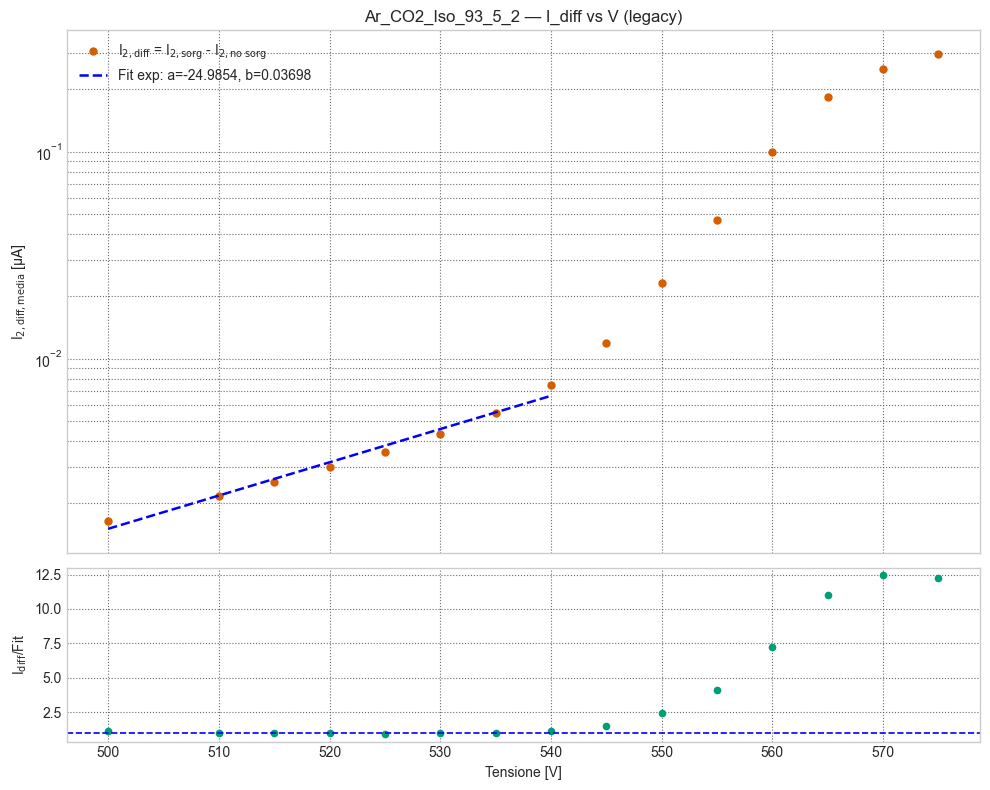

[Ar_CO2_Iso_93_5_2] Salvato: output/Ar_CO2_Iso_93_5_2/Ar_CO2_Iso_93_5_2_Idiff_vs_V_legacy.png
[Ar_CO2_Iso_93_5_2] Salvato: output/Ar_CO2_Iso_93_5_2/Ar_CO2_Iso_93_5_2_Idiff_vs_V_legacy.pdf
[Ar_CO2_Iso_88_10_2] primo punto escluso: V=490.0 V, I_diff=0.000663347 µA


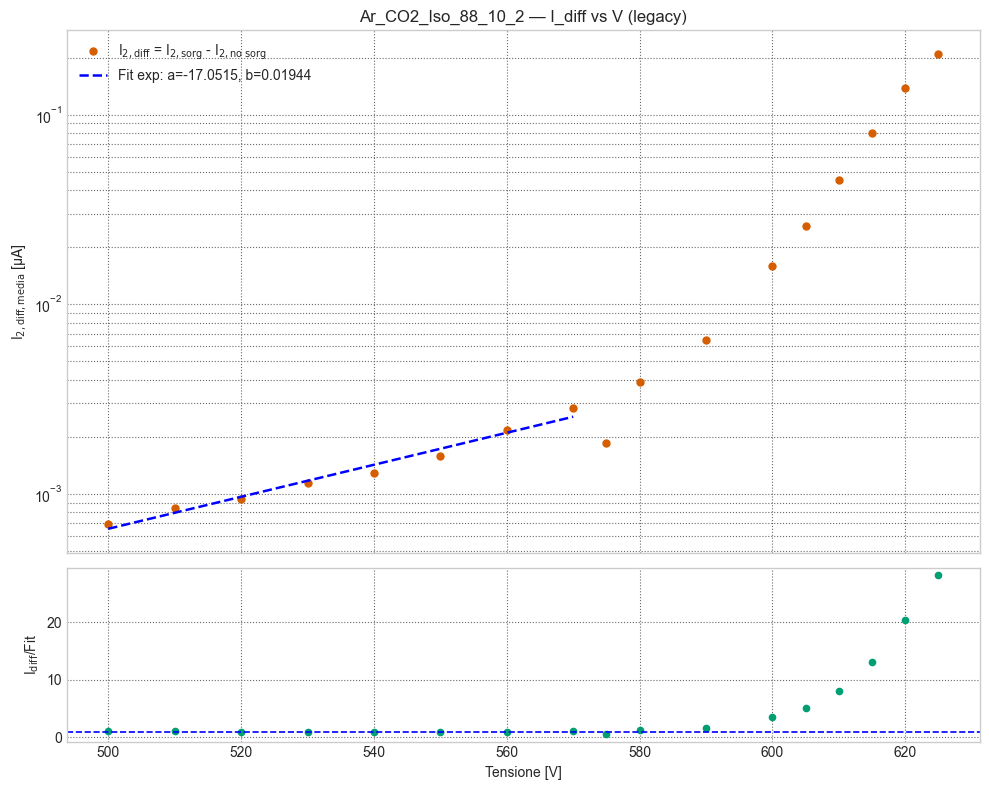

[Ar_CO2_Iso_88_10_2] Salvato: output/Ar_CO2_Iso_88_10_2/Ar_CO2_Iso_88_10_2_Idiff_vs_V_legacy.png
[Ar_CO2_Iso_88_10_2] Salvato: output/Ar_CO2_Iso_88_10_2/Ar_CO2_Iso_88_10_2_Idiff_vs_V_legacy.pdf

===== RIEPILOGO PLOT LEGACY =====


,miscela,csv_input,plot_png,plot_pdf,n_points,n_fit_points,excluded_first_point,a,b
0,Ar_CO2_Iso_93_5_2,output/Ar_CO2_Iso_93_5_2/Ar_CO2_Iso_93_5_2_I_t...,output/Ar_CO2_Iso_93_5_2/Ar_CO2_Iso_93_5_2_Idi...,output/Ar_CO2_Iso_93_5_2/Ar_CO2_Iso_93_5_2_Idi...,15,8,True,-24.985358,0.036978
1,Ar_CO2_Iso_88_10_2,output/Ar_CO2_Iso_88_10_2/Ar_CO2_Iso_88_10_2_I...,output/Ar_CO2_Iso_88_10_2/Ar_CO2_Iso_88_10_2_I...,output/Ar_CO2_Iso_88_10_2/Ar_CO2_Iso_88_10_2_I...,17,8,True,-17.051538,0.019439


In [23]:
# Plot legacy: I_diff vs V con fit esponenziale + pannello I_diff/Fit
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

output_dir = Path('output')
VOLTAGE_BIN_STEP_LEGACY = 5.0
N_FIT_POINTS_LEGACY = 8  # numero di punti iniziali usati nel fit in spazio log
EXCLUDE_FIRST_POINT_LEGACY = True  # <-- richiesta: escludi il primo punto

legacy_rows = []

for cfg in MIXTURE_CONFIGS:
    mix = cfg['name']
    mix_out = output_dir / mix
    csv_path = mix_out / f'{mix}_I_table.csv'

    if not csv_path.exists():
        print(f'[{mix}] file non trovato: {csv_path} — salto.')
        continue

    df = pd.read_csv(csv_path)

    # Colonna tensione: preferisci V2_ref (pipeline corrente), fallback robusto
    if 'V2_ref' in df.columns:
        v_col = 'V2_ref'
    else:
        v_candidates = [c for c in df.columns if c.startswith('V2')] or [c for c in df.columns if c.startswith('V_')]
        if not v_candidates:
            print(f'[{mix}] nessuna colonna tensione trovata in {csv_path} — salto.')
            continue
        v_col = v_candidates[0]

    # Colonna differenza corrente
    diff_col = next((c for c in ['I2_diff', 'I_diff', 'I3_diff'] if c in df.columns), None)
    if diff_col is None:
        print(f'[{mix}] nessuna colonna differenza corrente trovata in {csv_path} — salto.')
        continue

    work = df[[v_col, diff_col]].copy()
    work.columns = ['V', 'I_diff']
    work['V'] = pd.to_numeric(work['V'], errors='coerce')
    work['I_diff'] = pd.to_numeric(work['I_diff'], errors='coerce')
    work = work.dropna(subset=['V', 'I_diff'])
    work = work[work['I_diff'] > 0].copy()

    if work.empty:
        print(f'[{mix}] nessun punto con I_diff > 0 — salto.')
        continue

    # Binning in tensione (coerente col resto del notebook)
    work['V_round'] = (work['V'] / VOLTAGE_BIN_STEP_LEGACY).round() * VOLTAGE_BIN_STEP_LEGACY
    grouped = work.groupby('V_round', as_index=False)['I_diff'].mean().sort_values('V_round').reset_index(drop=True)
    grouped.columns = ['V', 'I_diff_mean']

    # Escludi il primo punto (più bassa tensione)
    if EXCLUDE_FIRST_POINT_LEGACY and len(grouped) > 1:
        dropped_v = float(grouped.iloc[0]['V'])
        dropped_i = float(grouped.iloc[0]['I_diff_mean'])
        grouped = grouped.iloc[1:].reset_index(drop=True)
        print(f'[{mix}] primo punto escluso: V={dropped_v:.1f} V, I_diff={dropped_i:.6g} µA')

    # Fit esponenziale sui primi N punti in scala log: ln(I)=a+bV => I=exp(a+bV)
    fit_df = grouped.head(min(N_FIT_POINTS_LEGACY, len(grouped))).copy()
    if len(fit_df) < 2:
        print(f'[{mix}] punti insufficienti per il fit dopo esclusione primo punto — salto.')
        continue

    b, a = np.polyfit(fit_df['V'].to_numpy(dtype=float), np.log(fit_df['I_diff_mean'].to_numpy(dtype=float)), 1)
    grouped['fit'] = np.exp(a + b * grouped['V'])
    fit_df['fit'] = np.exp(a + b * fit_df['V'])
    grouped['ratio'] = grouped['I_diff_mean'] / grouped['fit']

    fig, (ax_top, ax_ratio) = plt.subplots(
        2, 1, figsize=(10, 8), sharex=True,
        gridspec_kw={'height_ratios': [3, 1]}
    )

    # Top: dati + fit
    ax_top.plot(
        grouped['V'], grouped['I_diff_mean'],
        linestyle='None', marker='o', markersize=5,
        color='#D55E00',
        label=r'I$_{2,\mathrm{diff}}$ = I$_{2,\mathrm{sorg}}$ - I$_{2,\mathrm{no\ sorg}}$'
    )
    ax_top.plot(
        fit_df['V'], fit_df['fit'],
        linestyle='--', linewidth=1.8, color='blue',
        label=f'Fit exp: a={a:.4f}, b={b:.5f}'
    )
    ax_top.set_yscale('log')
    ax_top.set_ylabel(r'I$_{2,\mathrm{diff,media}}$ [µA]')
    ax_top.grid(True, which='both', linestyle=':', color='0.35', alpha=0.9)
    ax_top.legend(loc='upper left')
    ax_top.set_title(f'{mix} — I_diff vs V (legacy)')

    # Bottom: rapporto data/fit
    ax_ratio.plot(
        grouped['V'], grouped['ratio'],
        linestyle='None', marker='o', markersize=4.5,
        color='#009E73'
    )
    ax_ratio.axhline(1.0, color='blue', linestyle='--', linewidth=1.2)
    ax_ratio.set_xlabel('Tensione [V]')
    ax_ratio.set_ylabel(r'I$_{\mathrm{diff}}$/Fit')
    ax_ratio.grid(True, linestyle=':', color='0.35', alpha=0.9)

    fig.tight_layout()

    out_png = mix_out / f'{mix}_Idiff_vs_V_legacy.png'
    out_pdf = mix_out / f'{mix}_Idiff_vs_V_legacy.pdf'
    fig.savefig(out_png, dpi=200, bbox_inches='tight')
    fig.savefig(out_pdf, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    legacy_rows.append({
        'miscela': mix,
        'csv_input': str(csv_path),
        'plot_png': str(out_png),
        'plot_pdf': str(out_pdf),
        'n_points': int(len(grouped)),
        'n_fit_points': int(len(fit_df)),
        'excluded_first_point': bool(EXCLUDE_FIRST_POINT_LEGACY),
        'a': float(a),
        'b': float(b),
    })

    print(f'[{mix}] Salvato: {out_png}')
    print(f'[{mix}] Salvato: {out_pdf}')

print('\n===== RIEPILOGO PLOT LEGACY =====')
if legacy_rows:
    display(pd.DataFrame(legacy_rows))
else:
    print('Nessun plot legacy generato.')